# Training on digits (Part 2)

In [1]:
import os
import sklearn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import sys
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
from nn import nn

### TO DO : 

1. Load the digits dataset through sklearn using sklearn.datasets.load_digits().
2. Split the data into training and validation sets.
3. Generate an instance of your NeuralNetwork class with a 64x16x64 autoencoder architecture.
4. Train your autoencoder on the training data.
5. Plot your training and validation loss by epoch.
6. Quantify your average reconstruction error over the validation set.
7. Explain why you chose the hyperparameter values you did.


## 1. Load Data

In [2]:
digits = sklearn.datasets.load_digits()
X = digits['data']
len(X), X, type(X), type(X[0]), len(X[0])

(1797,
 array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 numpy.ndarray,
 numpy.ndarray,
 64)

In [3]:
y = digits['target']
len(y), y

(1797, array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)))

## 2. Split into train/test

In [4]:
X = digits.data
y = digits.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Training shape: (1437, 64)
Validation shape: (360, 64)


## 3. Generate autoencoder

In [ ]:
architecture = [{'input_dim': 64, 'output_dim': 16, 'activation': 'relu'}, {'input_dim': 16, 'output_dim': 64, 'activation': 'sigmoid'}]
potential_lrs = [0.001, 0.01, 0.1]
lr = potential_lrs[0]
potential_batches = [5, 10, 20]
seed = 42
batch_size = 20
epochs = 1000
loss_function = "mse"

labels = []
nns = []
for lr in potential_lrs:
    for batch in potential_batches:
        labels.append(f"BatchSize_{batch}_LR_{lr}")
        nns.append(nn.NeuralNetwork(architecture, lr, seed, batch, epochs, loss_function))

labels

['BatchSize_5_LR_0.001',
 'BatchSize_10_LR_0.001',
 'BatchSize_20_LR_0.001',
 'BatchSize_5_LR_0.01',
 'BatchSize_10_LR_0.01',
 'BatchSize_20_LR_0.01',
 'BatchSize_5_LR_0.1',
 'BatchSize_10_LR_0.1',
 'BatchSize_20_LR_0.1']

## 4. Train

In [6]:
trains = []
vals = []
for nn in nns:
    train_losses, val_losses = nn.fit(X_train, y_train, X_val, y_val)
    trains.append(train_losses)
    vals.append(val_losses)

## 5. Plot loss by epoch

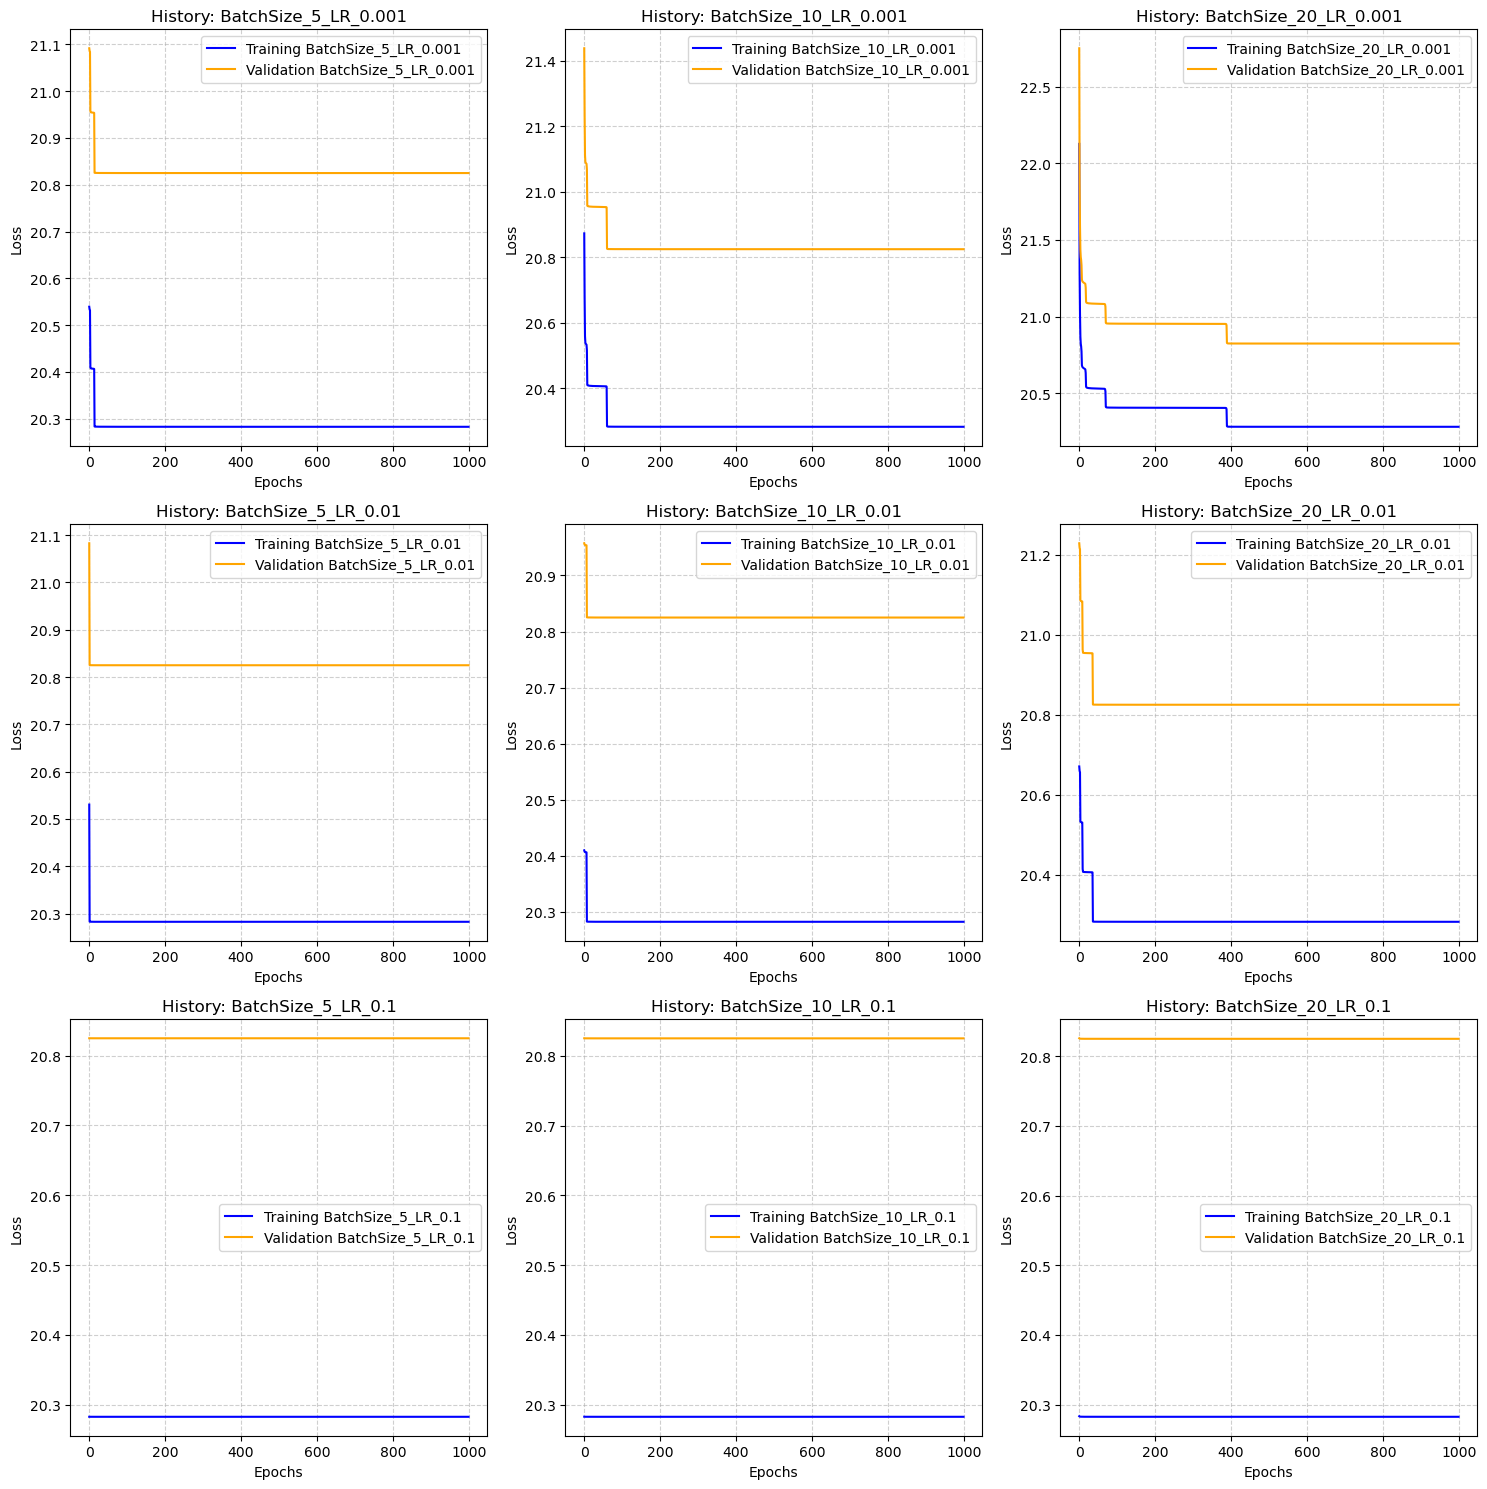

In [ ]:
import math
import matplotlib.pyplot as plt

n_plots = len(labels)
cols = 3
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten() 

for idx, (train, val) in enumerate(zip(trains, vals)):
    ax = axes[idx]
    label = labels[idx]
    
    ax.plot(train, label=f'Training {label}', color='blue')
    ax.plot(val, label=f'Validation {label}', color='orange')
    
    ax.set_title(f'History: {label}', fontsize=12)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 6. Quantify error

In [13]:
for idx, (train, val) in enumerate(zip(trains, vals)):
    avg_val_loss = float(np.mean(val))
    print(labels[idx])
    print(f"My average reconstruction error over the validation set: {avg_val_loss}")

BatchSize_5_LR_0.001
My average reconstruction error over the validation set: 20.827229914664684
BatchSize_10_LR_0.001
My average reconstruction error over the validation set: 20.834397789717716
BatchSize_20_LR_0.001
My average reconstruction error over the validation set: 20.890137180624922
BatchSize_5_LR_0.01
My average reconstruction error over the validation set: 20.825260532772226
BatchSize_10_LR_0.01
My average reconstruction error over the validation set: 20.825915590783573
BatchSize_20_LR_0.01
My average reconstruction error over the validation set: 20.83125582431176
BatchSize_5_LR_0.1
My average reconstruction error over the validation set: 20.82500018329271
BatchSize_10_LR_0.1
My average reconstruction error over the validation set: 20.825000899977283
BatchSize_20_LR_0.1
My average reconstruction error over the validation set: 20.82500455538638


#### **Final pick: BatchSize_5_LR_0.1 model, with an average reconstruction error of ~20.825**

## 7. Explain hyperparameters

I appealed to AI Overview from Google, asking "typical learning rates for 2 layer autoencoders", and it mentioned [0.001, 0.01, 0.1], so I tiled those three combinations against batch sizes of [5, 10, 20] to find the optimal combination.

I'm selecting the best performing model on the validation set, which is the BatchSize_5_LR_0.1 model, with an average reconstruction error of ~20.825, though it must be said they all had quite similar average errors even if they had different training trajectories.

*I'm aware that by doing so, I might be biasing my model towards the validation set. In a perfect ML problem, I would have also divided the data into a test set that would be the final evaluation; once testing on the test set, there would be no further iteration of hyperparameters or improvement.*